# 00. Data Exploration

Notebook ini berisi **eksplorasi data (EDA)** murni pada dataset pinjaman (Lending Club), sebelum masuk ke tahap preprocessing. Tujuannya untuk memahami kualitas data, profil peminjam, dan pola risiko kredit awal sebagai dasar keputusan pada tahap-tahap berikutnya.

**Pipeline notebook:** `00_Data_Exploration` → `01_Data_Preprocessing` → `02_Feature_Engineering` → `03_Modeling_ANN` → `04_Training_Evaluation` → `05_SHAP_Explainability` → `06_Deployment`

**Output notebook ini:** insight EDA (tidak ada artifact yang disimpan ke disk; proses pembersihan data dilanjutkan di `01_Data_Preprocessing.ipynb`).

---

# **Import Library**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')

# **Load Data**

In [4]:
path = "../data/raw"
df = pd.read_csv(path + "/loan.csv", low_memory=False)

print(f"Dataset shape: {df.shape[0]:,} baris × {df.shape[1]} kolom")
df.head(3)

Dataset shape: 887,379 baris × 74 kolom


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,1077501,1296599,5000.00,5000.00,4975.00,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.00,Verified,Dec-2011,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.00,Jan-1985,1.00,NaN,NaN,3.00,0.00,13648.00,83.70,9.00,f,0.00,0.00,5861.07,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-2015,171.62,NaN,Jan-2016,0.00,NaN,1.00,INDIVIDUAL,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1077430,1314167,2500.00,2500.00,2500.00,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.00,Source Verified,Dec-2011,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.00,Apr-1999,5.00,NaN,NaN,3.00,0.00,1687.00,9.40,4.00,f,0.00,0.00,1008.71,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-2013,119.66,NaN,Sep-2013,0.00,NaN,1.00,INDIVIDUAL,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1077175,1313524,2400.00,2400.00,2400.00,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.00,Not Verified,Dec-2011,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,small_business,real estate business,606xx,IL,8.72,0.00,Nov-2001,2.00,NaN,NaN,2.00,0.00,2956.00,98.50,10.00,f,0.00,0.00,3003.65,3003.65,2400.00,603.65,0.00,0.00,0.00,Jun-2014,649.91,NaN,Jan-2016,0.00,NaN,1.00,INDIVIDUAL,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **1. Kualitas Data (Missing Value dan Tipe Kolom)**

## Tipe Data

In [5]:
dtype_summary = df.dtypes.value_counts().rename("Jumlah Kolom")
print("\nRingkasan Tipe Data:")
print(dtype_summary.to_string())


Ringkasan Tipe Data:
float64    49
str        23
int64       2


## Missing Value

In [6]:
miss = df.isnull().mean().mul(100).sort_values(ascending=False)
miss = miss[miss > 0].rename("Missing (%)")

print(f"\nKolom dengan missing: {len(miss)} dari {df.shape[1]}")


Kolom dengan missing: 40 dari 74


In [7]:
def miss_level(pct):
    if pct >= 70: return "Kritis (≥70%)"
    elif pct >= 30: return "Tinggi (30–70%)"
    elif pct >= 10: return "Sedang (10–30%)"
    else: return "Rendah (<10%)"

miss_df = miss.reset_index()
miss_df.columns = ["Kolom", "Missing (%)"]
miss_df["Tingkat"] = miss_df["Missing (%)"].apply(miss_level)
display(miss_df.head(25))

,Kolom,Missing (%),Tingkat
0,dti_joint,99.94,Kritis (≥70%)
1,annual_inc_joint,99.94,Kritis (≥70%)
2,verification_status_joint,99.94,Kritis (≥70%)
3,il_util,97.90,Kritis (≥70%)
4,mths_since_rcnt_il,97.65,Kritis (≥70%)
5,inq_fi,97.59,Kritis (≥70%)
6,open_rv_24m,97.59,Kritis (≥70%)
7,open_acc_6m,97.59,Kritis (≥70%)
8,all_util,97.59,Kritis (≥70%)
9,inq_last_12m,97.59,Kritis (≥70%)


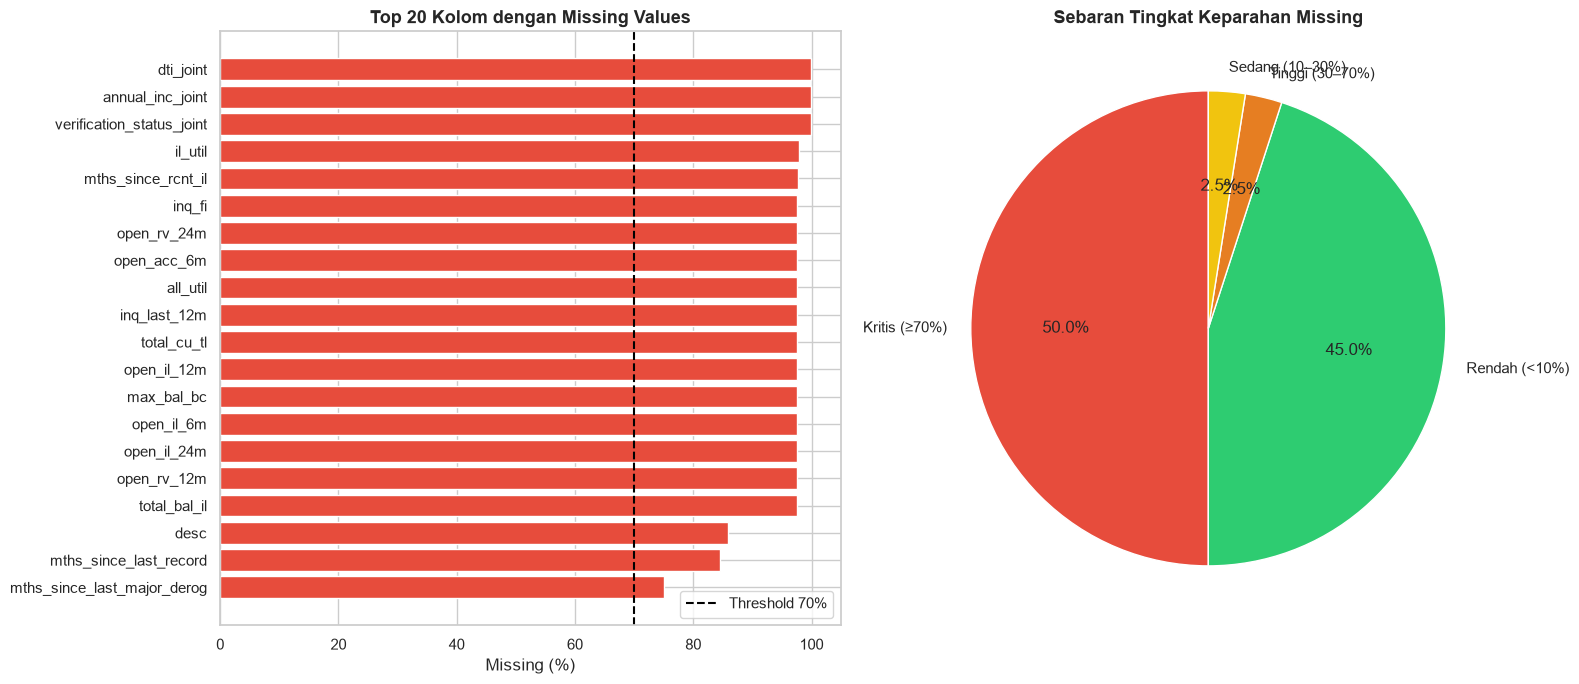

 20 kolom bersifat kritis
 18 kolom hanya sedikit missing


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Bar missing values
colors_map = {
    "Kritis (≥70%)": "#e74c3c",
    "Tinggi (30–70%)": "#e67e22",
    "Sedang (10–30%)": "#f1c40f",
    "Rendah (<10%)": "#2ecc71",
}
top20 = miss_df.head(20)
bar_colors = [colors_map[t] for t in top20["Tingkat"]]
axes[0].barh(top20["Kolom"][::-1], top20["Missing (%)"][::-1], color=bar_colors[::-1])
axes[0].axvline(70, color="black", linestyle="--", lw=1.5, label="Threshold 70%")
axes[0].set_title("Top 20 Kolom dengan Missing Values", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Missing (%)")
axes[0].legend()

# Pie tingkat keparahan
level_counts = miss_df["Tingkat"].value_counts()
pie_colors = [colors_map[k] for k in level_counts.index]
axes[1].pie(level_counts.values, labels=level_counts.index, autopct="%1.1f%%",
            colors=pie_colors, startangle=90)
axes[1].set_title("Sebaran Tingkat Keparahan Missing", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

print(f" {(miss_df['Tingkat']=='Kritis (≥70%)').sum()} kolom bersifat kritis")
print(f" {(miss_df['Tingkat']=='Rendah (<10%)').sum()} kolom hanya sedikit missing")

# **2. Seperti apa profile peminjam yang ada di dataset?**


Statistik Fitur Numerik Utama:


,count,mean,std,min,25%,50%,75%,max
loan_amnt,887379.00,14755.26,8435.46,500.00,8000.00,13000.00,20000.00,35000.00
annual_inc,887375.00,75027.59,64698.30,0.00,45000.00,65000.00,90000.00,9500000.00
dti,887379.00,18.16,17.19,0.00,11.91,17.65,23.95,9999.00
int_rate,887379.00,13.25,4.38,5.32,9.99,12.99,16.20,28.99
installment,887379.00,436.72,244.19,15.67,260.70,382.55,572.60,1445.46
open_acc,887350.00,11.55,5.32,0.00,8.00,11.00,14.00,90.00
revol_bal,887379.00,16920.79,22426.79,0.00,6443.00,11875.00,20829.00,2904836.00


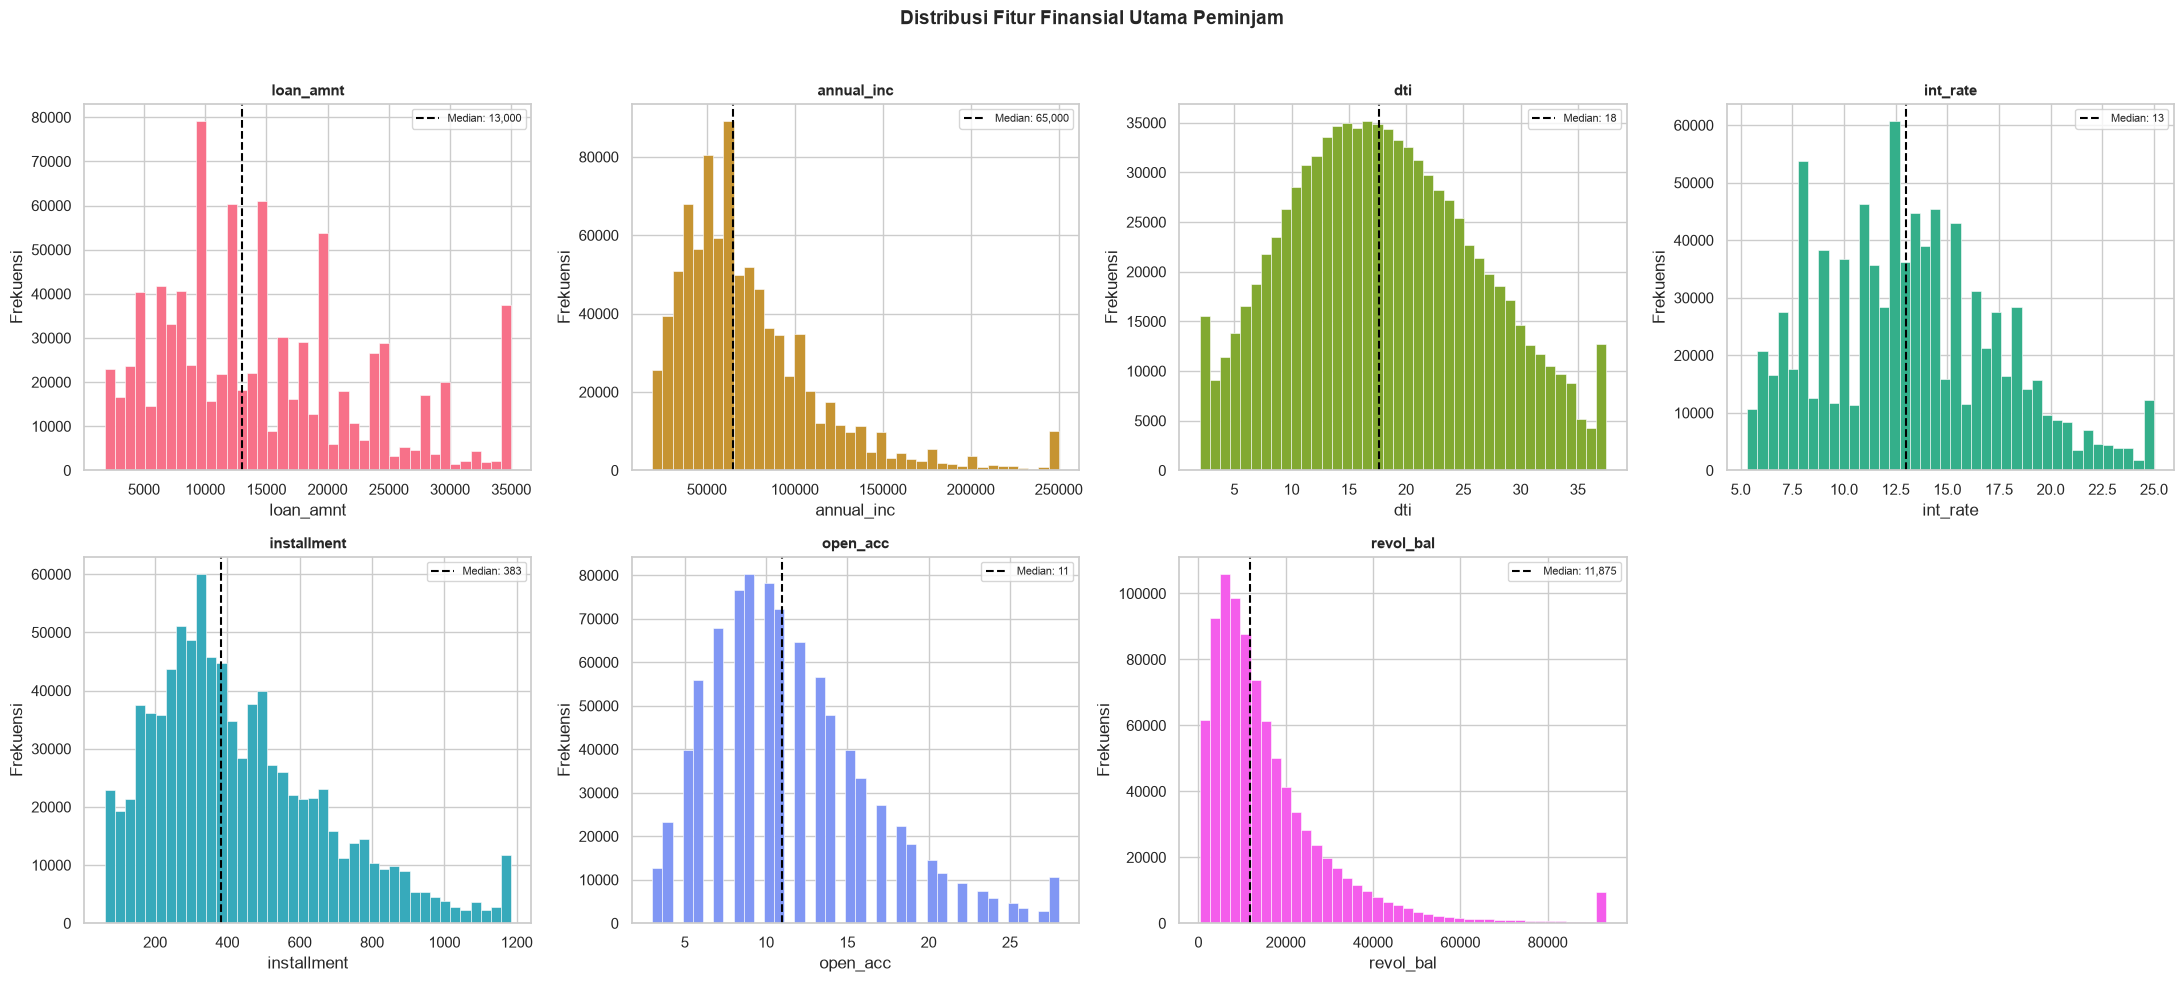

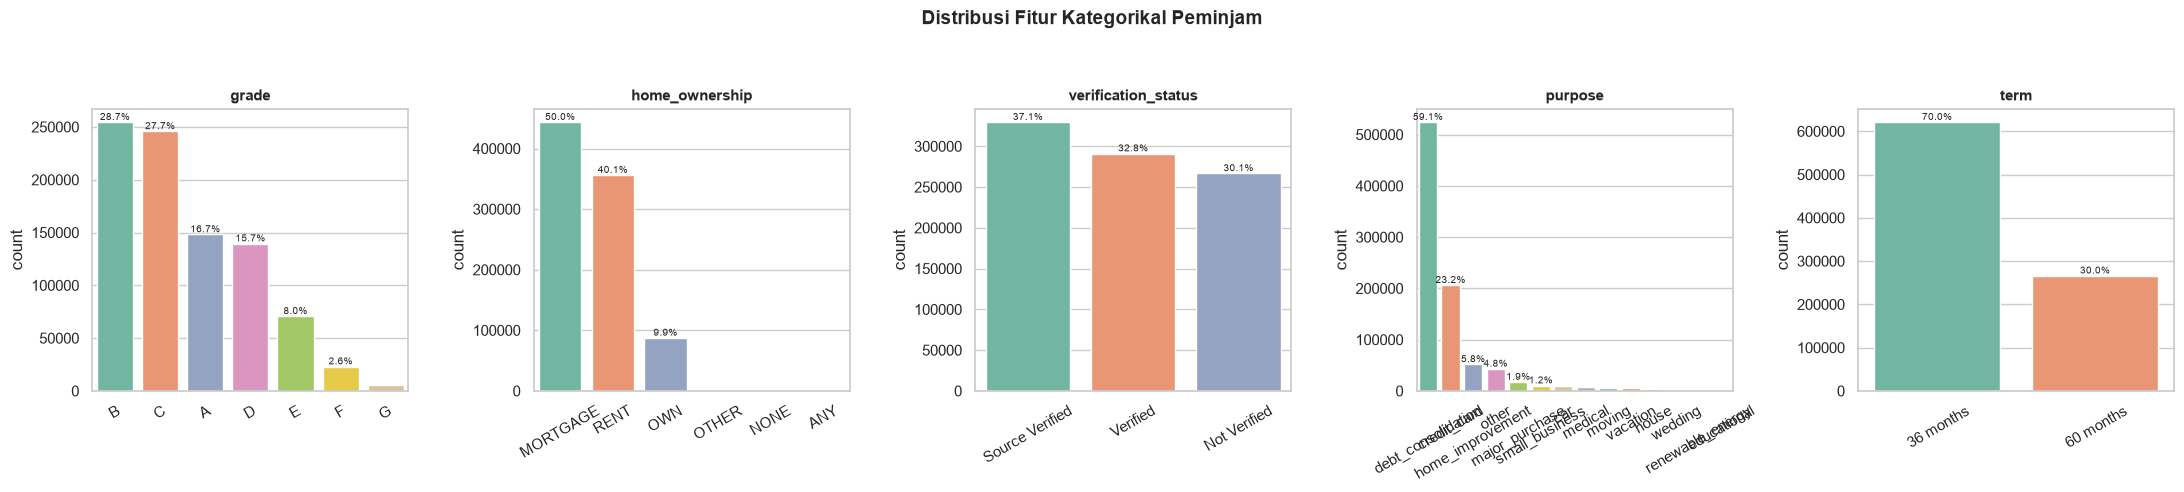

In [9]:
focus_num = ['loan_amnt', 'annual_inc', 'dti', 'int_rate', 'installment', 'open_acc', 'revol_bal']
focus_cat = ['grade', 'home_ownership', 'verification_status', 'purpose', 'term']

# Konversi sementara untuk EDA
df_eda = df.copy()
if 'int_rate' in df_eda.columns:
    df_eda['int_rate'] = pd.to_numeric(df_eda['int_rate'].astype(str).str.replace('%', '').str.strip(), errors='coerce')
if 'revol_util' in df_eda.columns:
    df_eda['revol_util'] = pd.to_numeric(df_eda['revol_util'].astype(str).str.replace('%', '').str.strip(), errors='coerce')

# Statistik ringkas
print("\nStatistik Fitur Numerik Utama:")
display(df_eda[focus_num].describe().T.round(2))

# Visualisasi distribusi numerik
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

palette = sns.color_palette("husl", len(focus_num))
for i, col in enumerate(focus_num):
    if col not in df_eda.columns:
        axes[i].set_visible(False)
        continue
    p1, p99 = df_eda[col].quantile([0.01, 0.99])
    data_clip = df_eda[col].clip(p1, p99).dropna()
    axes[i].hist(data_clip, bins=40, color=palette[i], edgecolor='white', linewidth=0.4)
    axes[i].axvline(data_clip.median(), color='black', linestyle='--', lw=1.5, label=f'Median: {data_clip.median():,.0f}')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=8)

for j in range(len(focus_num), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distribusi Fitur Finansial Utama Peminjam", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Distribusi kategorikal
fig, axes = plt.subplots(1, len([c for c in focus_cat if c in df_eda.columns]), figsize=(22, 5))
for i, col in enumerate([c for c in focus_cat if c in df_eda.columns]):
    order = df_eda[col].value_counts().index
    sns.countplot(data=df_eda, x=col, order=order, palette='Set2', ax=axes[i])
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    total = len(df_eda[col].dropna())
    for p in axes[i].patches:
        pct = p.get_height() / total * 100
        if pct > 1:
            axes[i].annotate(f'{pct:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                             ha='center', va='bottom', fontsize=7.5)

fig.suptitle("Distribusi Fitur Kategorikal Peminjam", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# **3. Seberapa seimbang kelas target?**

,Jumlah,Persentase (%)
loan_status,,
Current,601779,67.82
Fully Paid,207723,23.41
Charged Off,45248,5.10
Late (31-120 days),11591,1.31
Issued,8460,0.95
In Grace Period,6253,0.70
Late (16-30 days),2357,0.27
Does not meet the credit policy. Status:Fully Paid,1988,0.22
Default,1219,0.14


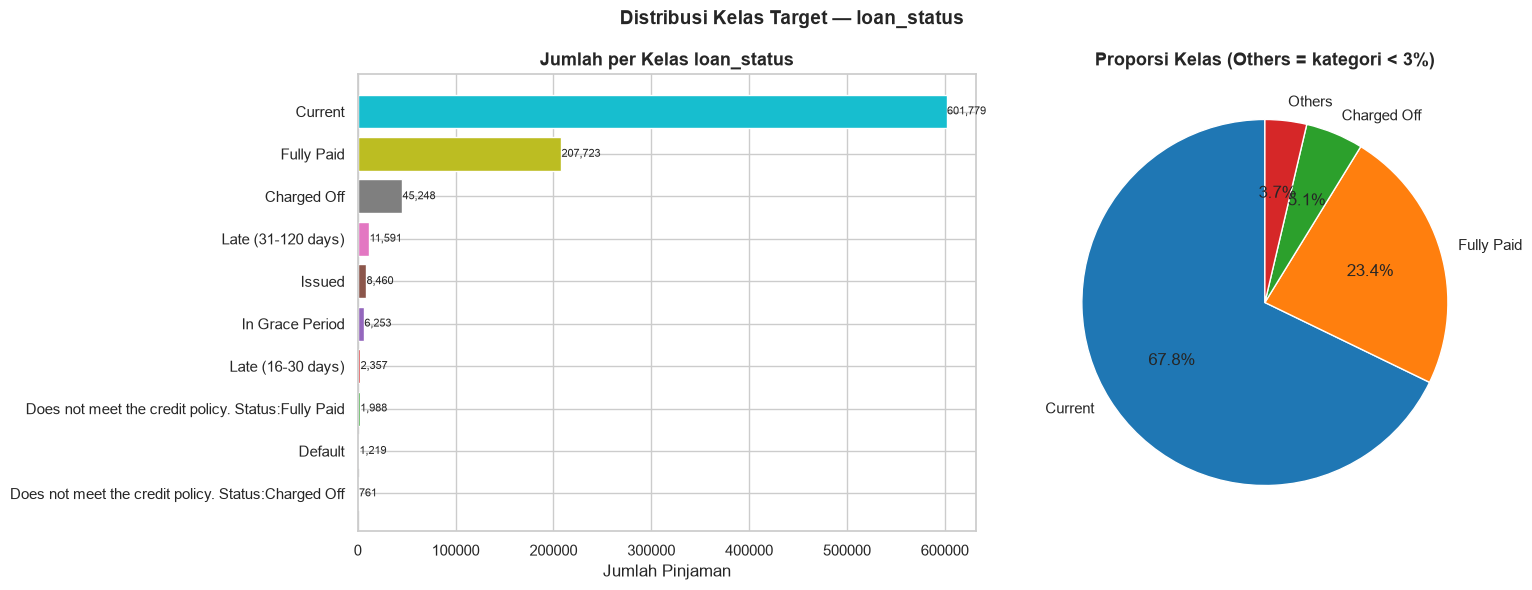

 Kelas dominan: 'Current' (67.8% dari total data)
 7 kelas memiliki proporsi < 3%


In [10]:
status_counts = df['loan_status'].value_counts()
status_pct = status_counts / len(df) * 100

summary_target = pd.DataFrame({
    'Jumlah': status_counts,
    'Persentase (%)': status_pct.round(2)
})
display(summary_target)

# Kelompokkan kategori kecil (< 3%) ke Others
threshold = 3
large = status_pct[status_pct >= threshold]
small = status_pct[status_pct < threshold]
pie_counts = status_counts[large.index].copy()
if len(small) > 0:
    pie_counts['Others'] = status_counts[small.index].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = sns.color_palette("tab10", len(pie_counts))

# Bar chart
axes[0].barh(status_counts.index[::-1], status_counts.values[::-1],
             color=sns.color_palette("tab10", len(status_counts)))
axes[0].set_title("Jumlah per Kelas loan_status", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Jumlah Pinjaman")
for i, (val, idx) in enumerate(zip(status_counts.values[::-1], status_counts.index[::-1])):
    axes[0].text(val + 500, i, f'{val:,}', va='center', fontsize=8)

# Pie chart
axes[1].pie(pie_counts.values, labels=pie_counts.index, autopct='%1.1f%%',
            colors=palette, startangle=90)
axes[1].set_title("Proporsi Kelas (Others = kategori < 3%)", fontsize=13, fontweight='bold')

fig.suptitle("Distribusi Kelas Target — loan_status", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

dominant = status_counts.index[0]
dominant_pct = status_pct.iloc[0]
print(f" Kelas dominan: '{dominant}' ({dominant_pct:.1f}% dari total data)")
print(f" {len(small)} kelas memiliki proporsi < 3%")

# **4. Apakah grade pinjaman mencerminkan risiko gagal bayar?**

,grade,total,risky,risk_rate (%)
0,A,148202,3298,2.23
1,B,254535,12216,4.80
2,C,245860,17167,6.98
3,D,139542,14454,10.36
4,E,70705,8837,12.50
5,F,23046,4029,17.48
6,G,5489,1175,21.41


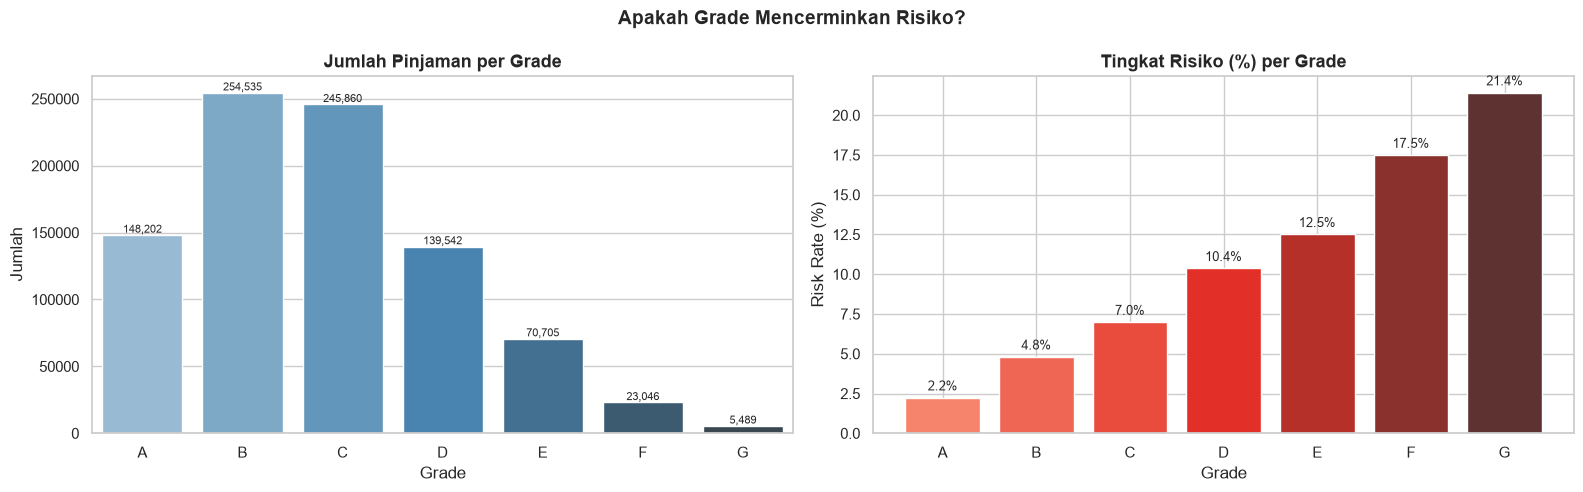

 Grade A paling aman, Grade G paling berisiko


In [11]:
# Binarize: 1 = berisiko (Charged Off, Default, Late), 0 = aman
risky_status = ['Charged Off', 'Default', 'Late (31-120 days)', 'Late (16-30 days)',
                'Does not meet the credit policy. Status:Charged Off']

df_eda['is_risky'] = df_eda['loan_status'].isin(risky_status).astype(int)

if 'grade' in df_eda.columns:
    grade_risk = df_eda.groupby('grade').agg(
        total=('is_risky', 'count'),
        risky=('is_risky', 'sum')
    ).reset_index()
    grade_risk['risk_rate (%)'] = (grade_risk['risky'] / grade_risk['total'] * 100).round(2)
    grade_risk = grade_risk.sort_values('grade')

    display(grade_risk)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Bar: jumlah pinjaman per grade
    sns.barplot(data=grade_risk, x='grade', y='total', palette='Blues_d', ax=axes[0])
    axes[0].set_title("Jumlah Pinjaman per Grade", fontsize=13, fontweight='bold')
    axes[0].set_xlabel("Grade"); axes[0].set_ylabel("Jumlah")
    for p in axes[0].patches:
        axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                         ha='center', va='bottom', fontsize=8)

    # Bar: tingkat risiko per grade
    bars = axes[1].bar(grade_risk['grade'], grade_risk['risk_rate (%)'],
                       color=sns.color_palette("Reds_d", len(grade_risk)))
    axes[1].set_title("Tingkat Risiko (%) per Grade", fontsize=13, fontweight='bold')
    axes[1].set_xlabel("Grade"); axes[1].set_ylabel("Risk Rate (%)")
    for bar, val in zip(bars, grade_risk['risk_rate (%)']):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

    fig.suptitle("Apakah Grade Mencerminkan Risiko?", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    best = grade_risk.loc[grade_risk['risk_rate (%)'].idxmin(), 'grade']
    worst = grade_risk.loc[grade_risk['risk_rate (%)'].idxmax(), 'grade']
    print(f" Grade {best} paling aman, Grade {worst} paling berisiko")

# **5. Apakah suku bunga (int_rate) dan DTI (debt-to-income) berbeda secara signifikan antara peminjam yang gagal bayar dan yang tidak?**

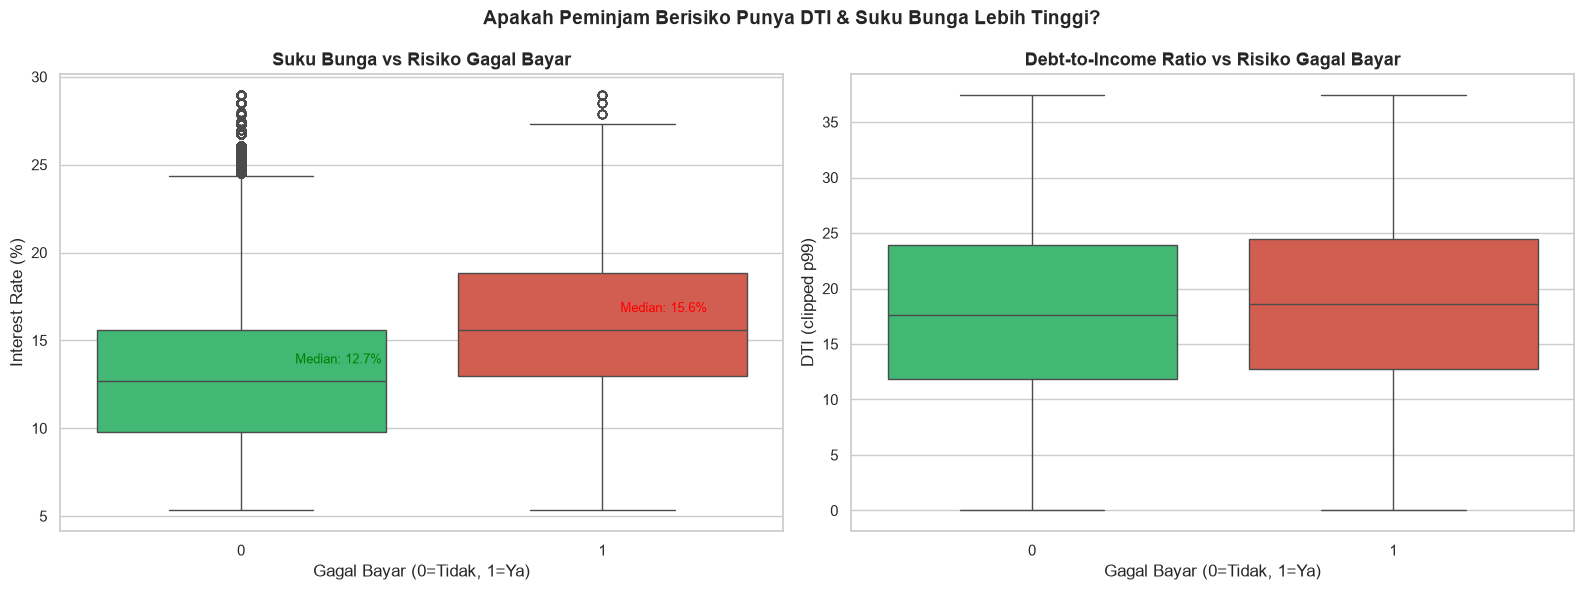

 Median int_rate peminjam gagal bayar lebih tinggi 2.9% dari yang tidak
 DTI juga cenderung lebih tinggi pada kelompok berisiko


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# int_rate
if 'int_rate' in df_eda.columns:
    sns.boxplot(data=df_eda, x='is_risky', y='int_rate', palette=['#2ecc71', '#e74c3c'], ax=axes[0])
    axes[0].set_title("Suku Bunga vs Risiko Gagal Bayar", fontsize=13, fontweight='bold')
    axes[0].set_xlabel("Gagal Bayar (0=Tidak, 1=Ya)")
    axes[0].set_ylabel("Interest Rate (%)")

    med0 = df_eda.loc[df_eda['is_risky']==0, 'int_rate'].median()
    med1 = df_eda.loc[df_eda['is_risky']==1, 'int_rate'].median()
    axes[0].annotate(f'Median: {med0:.1f}%', xy=(0, med0), xytext=(0.15, med0+1), fontsize=9, color='green')
    axes[0].annotate(f'Median: {med1:.1f}%', xy=(1, med1), xytext=(1.05, med1+1), fontsize=9, color='red')

# dti
if 'dti' in df_eda.columns:
    dti_clip = df_eda['dti'].clip(0, df_eda['dti'].quantile(0.99))
    df_plot = df_eda.copy()
    df_plot['dti_clipped'] = dti_clip
    sns.boxplot(data=df_plot, x='is_risky', y='dti_clipped', palette=['#2ecc71', '#e74c3c'], ax=axes[1])
    axes[1].set_title("Debt-to-Income Ratio vs Risiko Gagal Bayar", fontsize=13, fontweight='bold')
    axes[1].set_xlabel("Gagal Bayar (0=Tidak, 1=Ya)")
    axes[1].set_ylabel("DTI (clipped p99)")

fig.suptitle("Apakah Peminjam Berisiko Punya DTI & Suku Bunga Lebih Tinggi?",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

if 'int_rate' in df_eda.columns:
    diff = med1 - med0
    print(f" Median int_rate peminjam gagal bayar lebih tinggi {diff:.1f}% dari yang tidak")
    print(f" DTI juga cenderung lebih tinggi pada kelompok berisiko")

# **6. Apakah tujuan pinjaman (purpose) mempengaruhi tingkat risiko?**

,purpose,total,risky,risk_rate (%)
3,educational,423,88,20.80
11,small_business,10377,1702,16.40
13,wedding,2347,286,12.19
10,renewable_energy,575,64,11.13
8,moving,5414,564,10.42
5,house,3707,380,10.25
9,other,42894,3853,8.98
7,medical,8540,748,8.76
12,vacation,4736,365,7.71
2,debt_consolidation,524215,37610,7.17


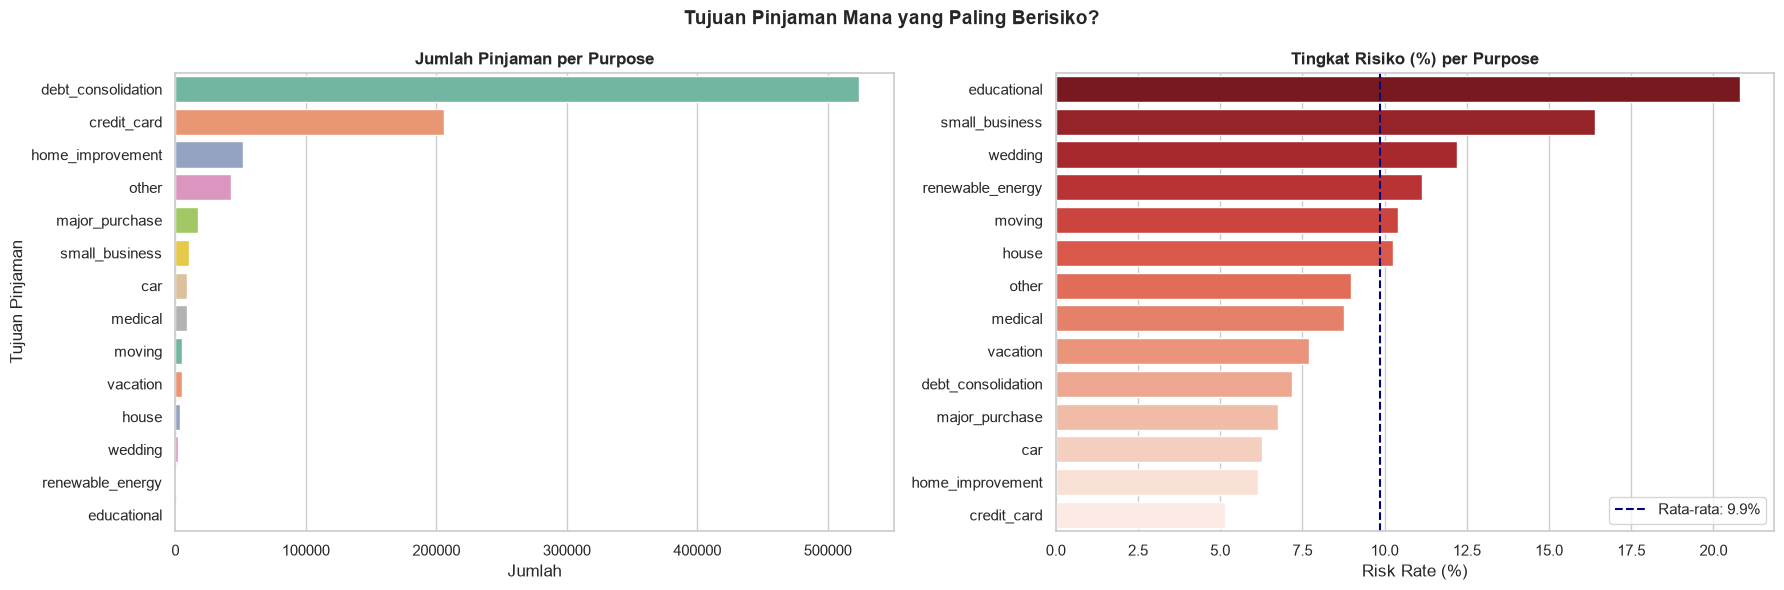

 Purpose paling berisiko: 'educational' (20.8%)
 Purpose paling aman: 'credit_card' (5.1%)


In [13]:
if 'purpose' in df_eda.columns:
    purpose_risk = df_eda.groupby('purpose').agg(
        total=('is_risky', 'count'),
        risky=('is_risky', 'sum')
    ).reset_index()
    purpose_risk['risk_rate (%)'] = (purpose_risk['risky'] / purpose_risk['total'] * 100).round(2)
    purpose_risk = purpose_risk.sort_values('risk_rate (%)', ascending=False)

    display(purpose_risk)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Jumlah pinjaman per purpose
    order_count = df_eda['purpose'].value_counts().index
    sns.countplot(data=df_eda, y='purpose', order=order_count, palette='Set2', ax=axes[0])
    axes[0].set_title("Jumlah Pinjaman per Purpose", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Jumlah"); axes[0].set_ylabel("Tujuan Pinjaman")

    # Risk rate per purpose
    sns.barplot(data=purpose_risk, y='purpose', x='risk_rate (%)',
                order=purpose_risk['purpose'], palette='Reds_r', ax=axes[1])
    axes[1].set_title("Tingkat Risiko (%) per Purpose", fontsize=12, fontweight='bold')
    axes[1].set_xlabel("Risk Rate (%)"); axes[1].set_ylabel("")
    axes[1].axvline(purpose_risk['risk_rate (%)'].mean(), color='navy', linestyle='--',
                    label=f"Rata-rata: {purpose_risk['risk_rate (%)'].mean():.1f}%")
    axes[1].legend()

    fig.suptitle("Tujuan Pinjaman Mana yang Paling Berisiko?",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    top_risk = purpose_risk.iloc[0]
    print(f" Purpose paling berisiko: '{top_risk['purpose']}' ({top_risk['risk_rate (%)']:.1f}%)")
    print(f" Purpose paling aman: '{purpose_risk.iloc[-1]['purpose']}' ({purpose_risk.iloc[-1]['risk_rate (%)']:.1f}%)")

# **7. Apakah panjang masa kerja (emp_length) berpengaruh pada kemampuan bayar?**

,emp_length,total,risky,risk_rate (%)
10,< 1 year,70605,5291,7.49
0,1 year,57095,4075,7.14
2,2 years,78870,5467,6.93
3,3 years,70026,4833,6.90
4,4 years,52529,3724,7.09
5,5 years,55704,4172,7.49
6,6 years,42950,3517,8.19
7,7 years,44594,3413,7.65
8,8 years,43955,2922,6.65
9,9 years,34657,2413,6.96


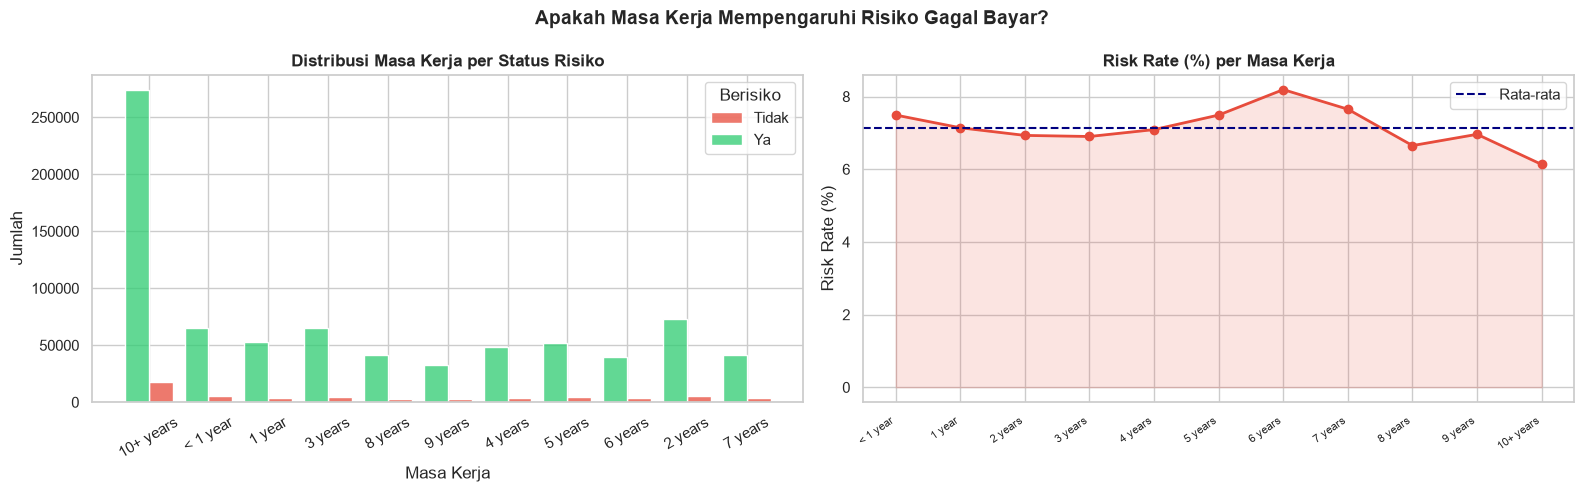

In [14]:
if 'emp_length' in df_eda.columns:
    # Hitung risk rate per emp_length
    emp_risk = df_eda.groupby('emp_length').agg(
        total=('is_risky', 'count'),
        risky=('is_risky', 'sum')
    ).reset_index()
    emp_risk['risk_rate (%)'] = (emp_risk['risky'] / emp_risk['total'] * 100).round(2)

    # Urutkan
    order_map = {'< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
                 '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9,
                 '10+ years': 10}
    emp_risk['order'] = emp_risk['emp_length'].map(order_map)
    emp_risk = emp_risk.sort_values('order').dropna(subset=['order'])

    display(emp_risk[['emp_length', 'total', 'risky', 'risk_rate (%)']])

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Distribusi emp_length per status (dodge)
    sns.histplot(data=df_eda, x='emp_length', hue='is_risky', multiple='dodge',
                 palette=['#2ecc71', '#e74c3c'], ax=axes[0], shrink=0.8)
    axes[0].set_title("Distribusi Masa Kerja per Status Risiko", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Masa Kerja"); axes[0].set_ylabel("Jumlah")
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].legend(title='Berisiko', labels=['Tidak', 'Ya'])

    # Risk rate line
    axes[1].plot(emp_risk['emp_length'], emp_risk['risk_rate (%)'],
                 marker='o', color='#e74c3c', linewidth=2, markersize=6)
    axes[1].fill_between(range(len(emp_risk)), emp_risk['risk_rate (%)'].values,
                         alpha=0.15, color='#e74c3c')
    axes[1].set_xticks(range(len(emp_risk)))
    axes[1].set_xticklabels(emp_risk['emp_length'], rotation=35, ha='right', fontsize=8)
    axes[1].set_title("Risk Rate (%) per Masa Kerja", fontsize=12, fontweight='bold')
    axes[1].set_ylabel("Risk Rate (%)")
    axes[1].axhline(emp_risk['risk_rate (%)'].mean(), color='navy', linestyle='--',
                    label='Rata-rata'); axes[1].legend()

    fig.suptitle("Apakah Masa Kerja Mempengaruhi Risiko Gagal Bayar?",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# **8. Fitur numerik mana yang paling berkorelasi?**


 Pasangan fitur dengan |korelasi| ≥ 0.7: 


,Fitur A,Fitur B,Korelasi
9,out_prncp,out_prncp_inv,1.00
0,id,member_id,1.00
1,loan_amnt,funded_amnt,1.00
10,total_pymnt,total_pymnt_inv,1.00
4,funded_amnt,funded_amnt_inv,1.00
2,loan_amnt,funded_amnt_inv,1.00
11,total_pymnt,total_rec_prncp,0.97
12,total_pymnt_inv,total_rec_prncp,0.97
5,funded_amnt,installment,0.95
3,loan_amnt,installment,0.94


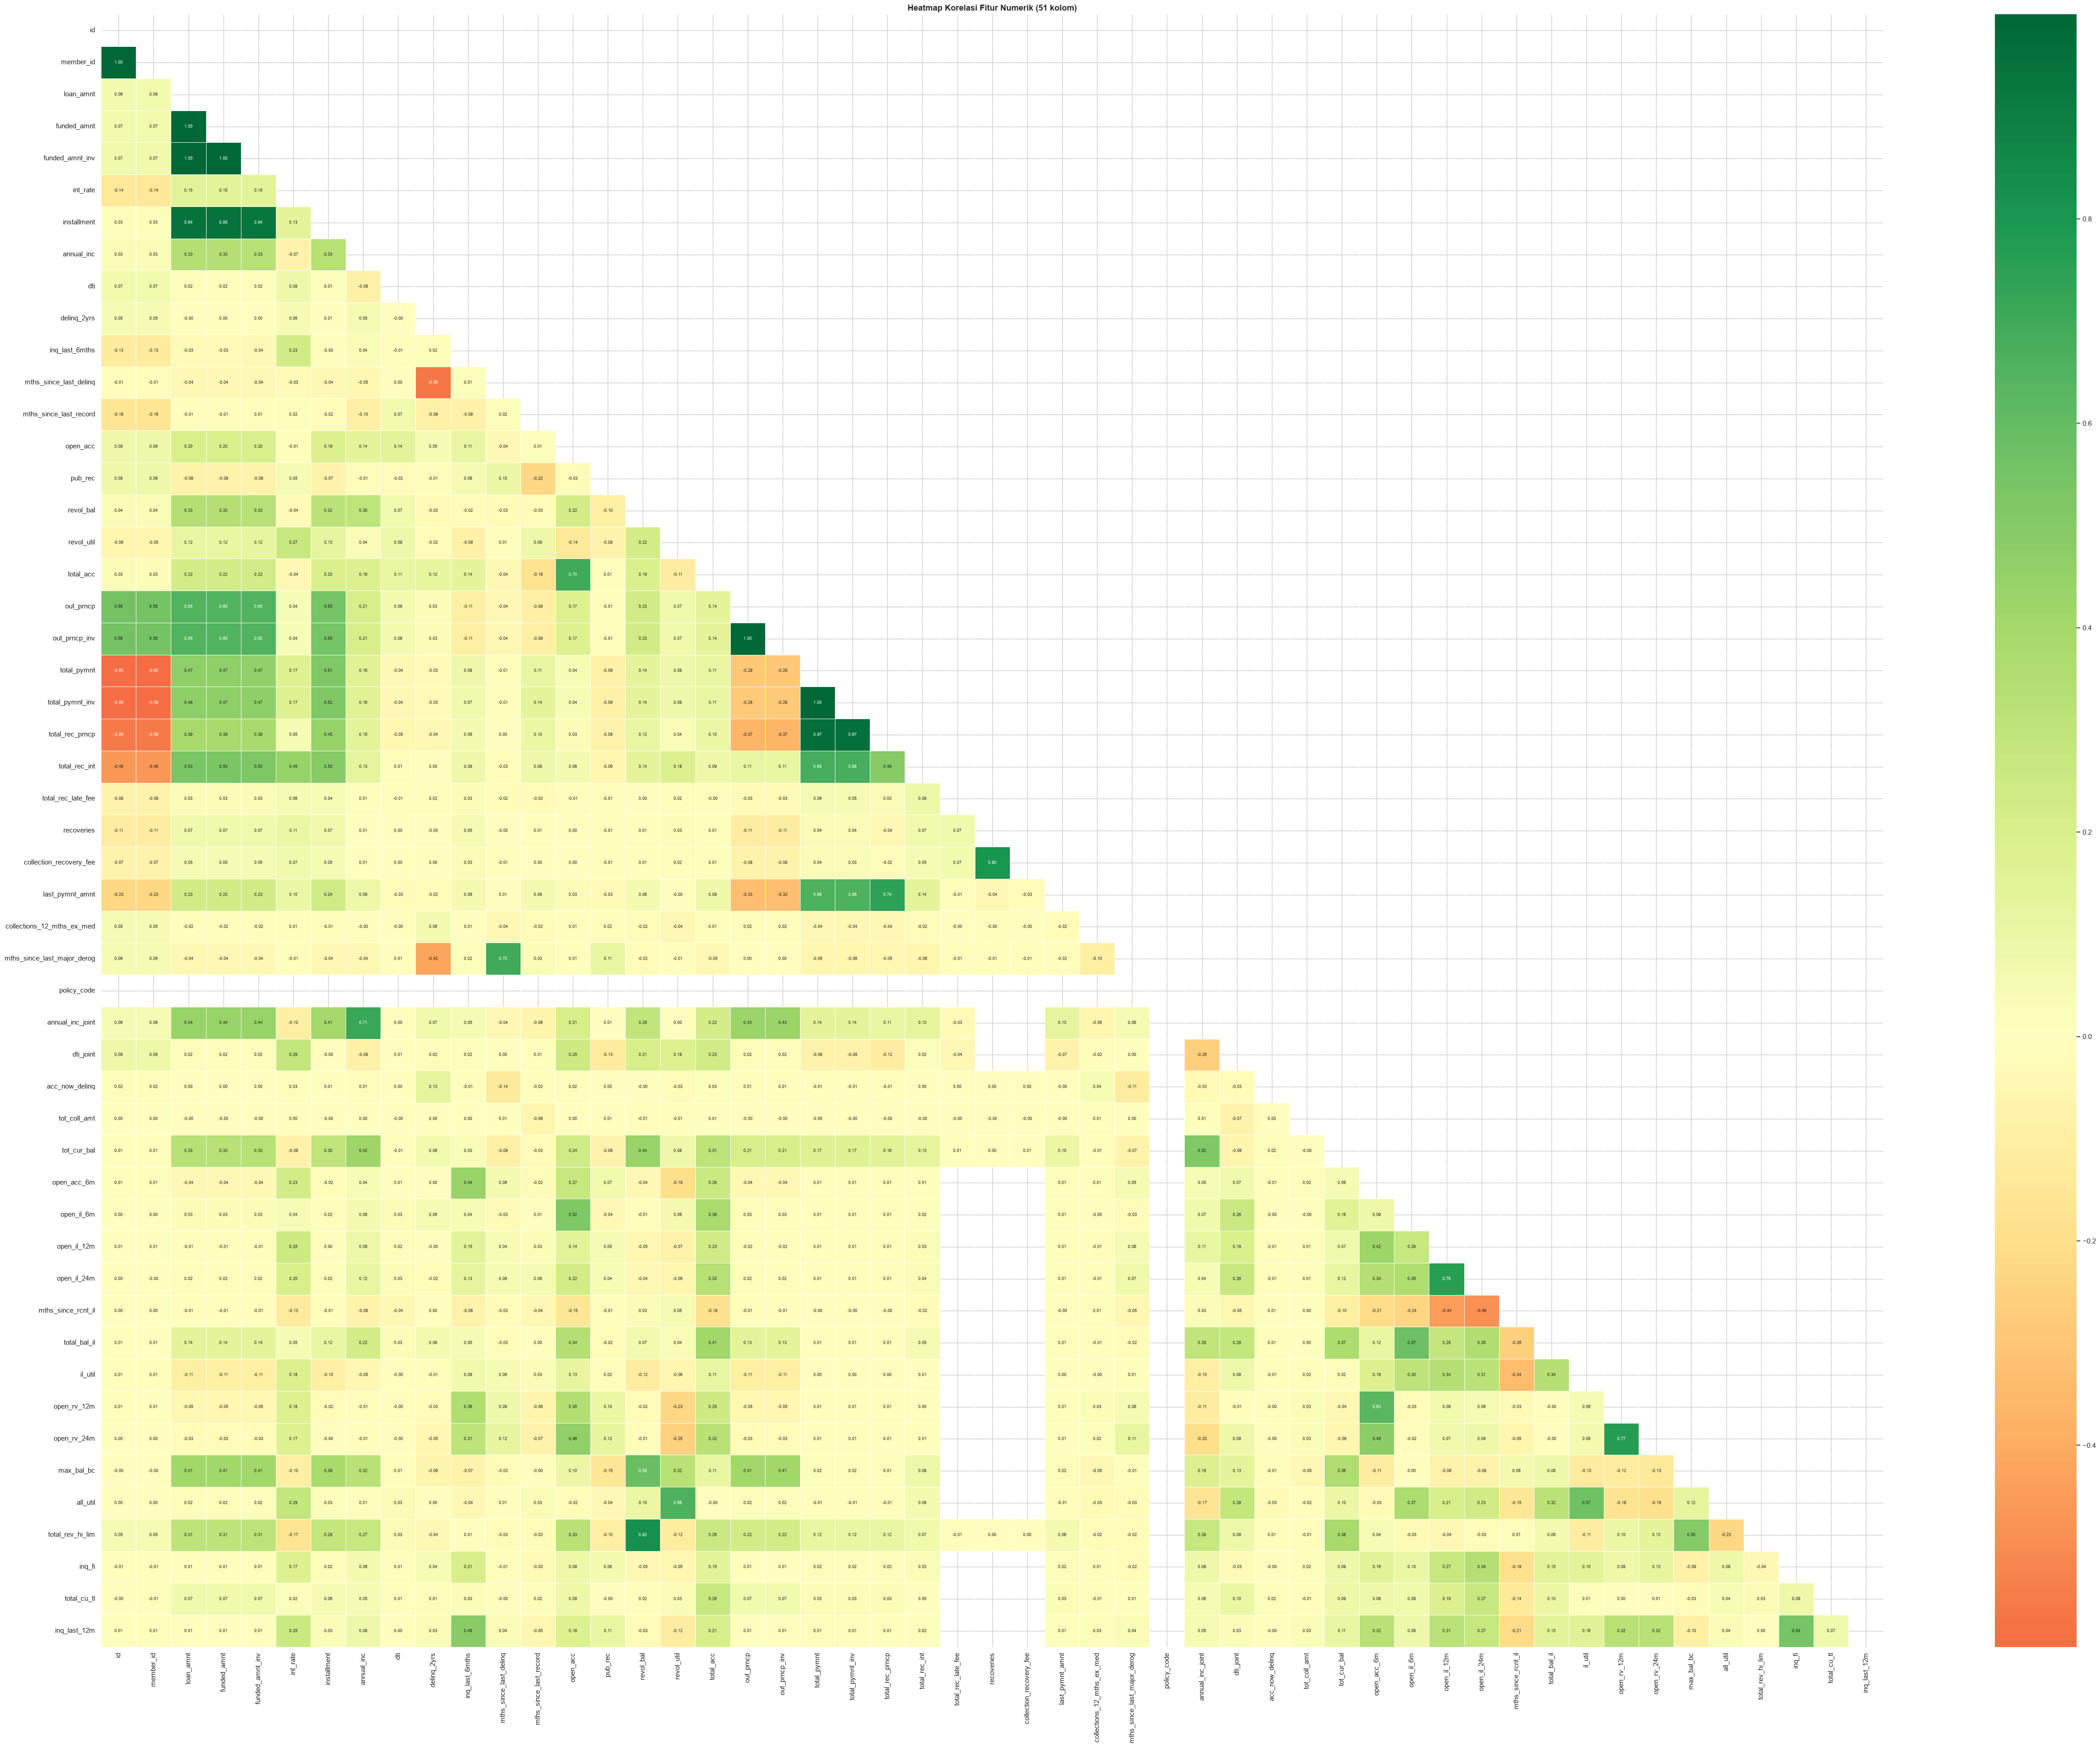

In [15]:
num_cols = df_eda.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in ['is_risky']]

corr = df_eda[num_cols].corr(numeric_only=True)

# Cari pasangan berkorelasi tinggi (|r| > 0.7)
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) >= 0.7:
            high_corr_pairs.append({
                'Fitur A': corr.columns[i],
                'Fitur B': corr.columns[j],
                'Korelasi': round(r, 3)
            })

print(f"\n Pasangan fitur dengan |korelasi| ≥ 0.7: ")
high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Korelasi', key=abs, ascending=False)
display(high_corr_df)

# Heatmap
fig_size = max(14, len(num_cols))
plt.figure(figsize=(fig_size, fig_size * 0.75))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, annot_kws={'size': 6.5})
plt.title(f"Heatmap Korelasi Fitur Numerik ({len(num_cols)} kolom)",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# **9. Bagaimana profile peminjam berbeda berdasarkan income, loan amount, dan home ownership?**

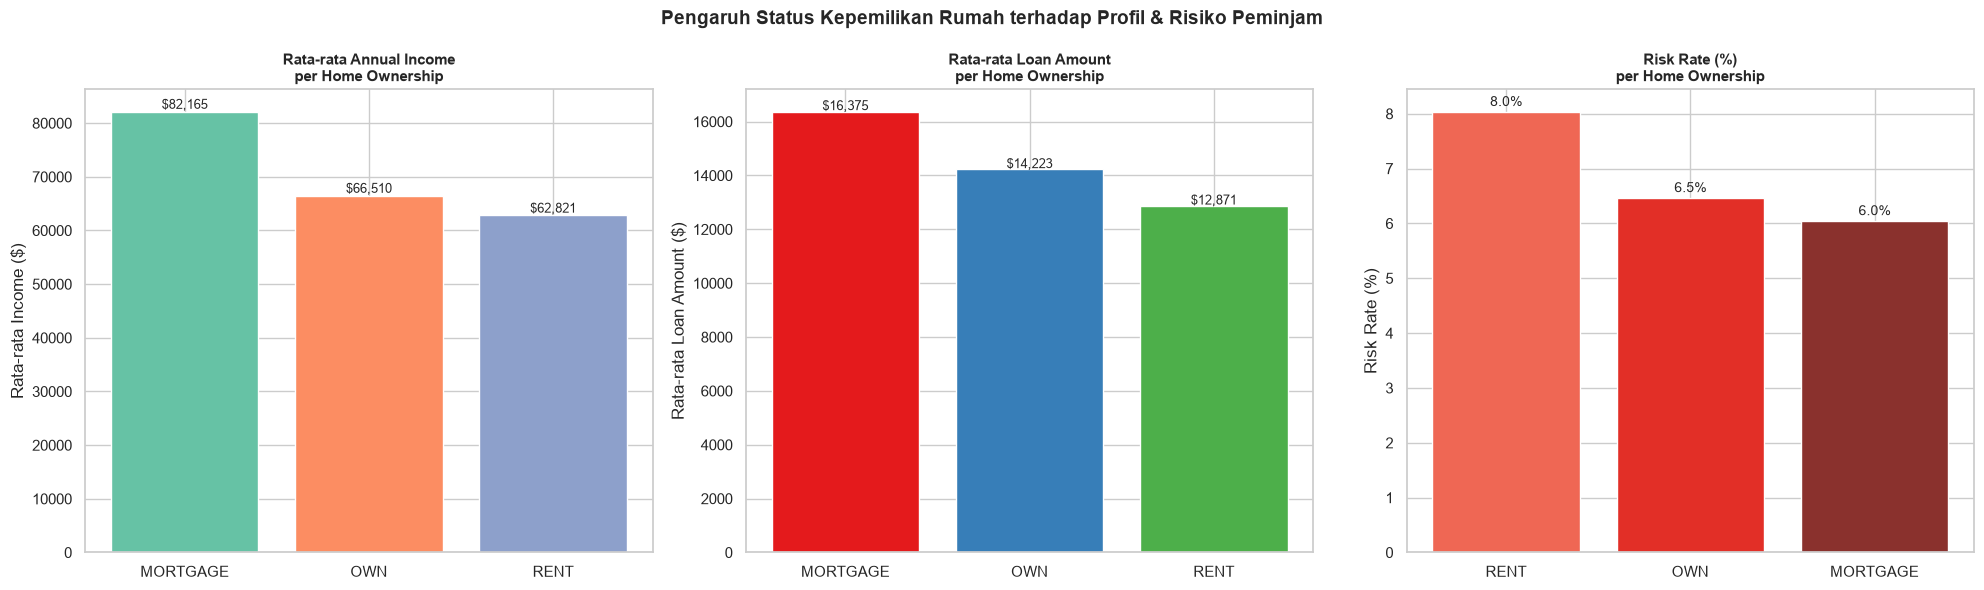

In [16]:
if all(c in df_eda.columns for c in ['annual_inc', 'loan_amnt', 'home_ownership']):
    # Clip outlier
    inc_clip = df_eda['annual_inc'].clip(0, df_eda['annual_inc'].quantile(0.98))
    loan_clip = df_eda['loan_amnt'].clip(0, df_eda['loan_amnt'].quantile(0.99))
    df_plot = df_eda.copy()
    df_plot['annual_inc_clip'] = inc_clip
    df_plot['loan_amnt_clip'] = loan_clip

    # Filter home_ownership utama
    main_ownership = ['RENT', 'OWN', 'MORTGAGE']
    df_plot = df_plot[df_plot['home_ownership'].isin(main_ownership)]

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Rata-rata income per home_ownership
    avg_inc = df_plot.groupby('home_ownership')['annual_inc_clip'].mean().sort_values(ascending=False)
    axes[0].bar(avg_inc.index, avg_inc.values,
                color=sns.color_palette("Set2", len(avg_inc)))
    axes[0].set_title("Rata-rata Annual Income\nper Home Ownership", fontsize=11, fontweight='bold')
    axes[0].set_ylabel("Rata-rata Income ($)")
    for i, (k, v) in enumerate(avg_inc.items()):
        axes[0].text(i, v + 500, f'${v:,.0f}', ha='center', fontsize=9)

    # Rata-rata loan amount per home_ownership
    avg_loan = df_plot.groupby('home_ownership')['loan_amnt_clip'].mean().sort_values(ascending=False)
    axes[1].bar(avg_loan.index, avg_loan.values,
                color=sns.color_palette("Set1", len(avg_loan)))
    axes[1].set_title("Rata-rata Loan Amount\nper Home Ownership", fontsize=11, fontweight='bold')
    axes[1].set_ylabel("Rata-rata Loan Amount ($)")
    for i, (k, v) in enumerate(avg_loan.items()):
        axes[1].text(i, v + 50, f'${v:,.0f}', ha='center', fontsize=9)

    # Risk rate per home_ownership
    own_risk = df_plot.groupby('home_ownership').agg(
        total=('is_risky', 'count'),
        risky=('is_risky', 'sum')
    ).reset_index()
    own_risk['risk_rate (%)'] = (own_risk['risky'] / own_risk['total'] * 100).round(2)
    own_risk = own_risk.sort_values('risk_rate (%)', ascending=False)
    bars = axes[2].bar(own_risk['home_ownership'], own_risk['risk_rate (%)'],
                       color=sns.color_palette("Reds_d", len(own_risk)))
    axes[2].set_title("Risk Rate (%)\nper Home Ownership", fontsize=11, fontweight='bold')
    axes[2].set_ylabel("Risk Rate (%)")
    for bar, val in zip(bars, own_risk['risk_rate (%)']):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                     f'{val:.1f}%', ha='center', fontsize=10)

    fig.suptitle("Pengaruh Status Kepemilikan Rumah terhadap Profil & Risiko Peminjam",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Ringkasan & Langkah Selanjutnya

Dari eksplorasi di atas diperoleh beberapa insight kunci:
- Dataset memiliki banyak kolom dengan missing value tinggi, kolom identifier, kolom teks bebas, dan kolom yang berpotensi *data leakage*.
- Distribusi kelas target (`loan_status`) sangat tidak seimbang.
- Beberapa fitur numerik (grade, int_rate, dti) menunjukkan hubungan yang jelas dengan risiko gagal bayar, menjadi kandidat kuat sebagai fitur model.

Insight ini menjadi dasar keputusan preprocessing yang dilakukan pada **`01_Data_Preprocessing.ipynb`**.